# Mission Eagle-1 — Pilote automatique d'atterrissage lunaire

## AstroDynamics · Apprentissage par renforcement

Dans cette mission, nous devons entraîner un **pilote automatique** capable de poser le module Eagle-1 en douceur sur la zone d'atterrissage de `LunarLander-v3`.

Le problème sera traité comme une boucle d'apprentissage par renforcement :

$$\text{état } s_t \longrightarrow \text{agent} \longrightarrow \text{action } a_t
\longrightarrow \text{environnement} \longrightarrow (s_{t+1}, r_t)$$

Le notebook suit toute la démarche expérimentale :

1. comprendre ce que l'agent voit et peut faire ;
2. mesurer une politique aléatoire ;
3. entraîner une baseline **DQN** avec les paramètres par défaut ;
4. analyser **PPO**, puis optimiser ses hyperparamètres avec **Optuna** ;
5. sélectionner le meilleur candidat avec un protocole commun ;
6. l'évaluer sur **100 épisodes indépendants** ;
7. sauvegarder le modèle, les logs et une vidéo de réussite.

> **Objectif de validation :** obtenir une récompense moyenne strictement supérieure à **200** sur 100 épisodes d'évaluation, sans confondre une réussite isolée avec une performance stable.

## 1. Livrables et stratégie expérimentale

Le notebook constitue le cœur analytique d'un ensemble plus large : modèle sauvegardé, API, GUI, dashboard et vidéo. Pour ne pas devoir reconstruire les informations après l'entraînement, les données sont enregistrées dès maintenant à trois niveaux.

| Niveau | Exemples d'informations enregistrées | Usage futur |
|---|---|---|
| **Expérience** | algorithme, seed, hyperparamètres, durée, score moyen | comparer les runs |
| **Épisode** | récompense, longueur, réussite/crash, position finale, moteurs | dashboard et validation |
| **Pas de temps** | état, action, récompense, valeurs Q/probabilités | analyser une trajectoire |

### Pourquoi étudier DQN **et** PPO ?

- `LunarLander-v3` possède quatre actions **discrètes** : DQN est donc un choix naturel et constitue la baseline explicitement attendue.
- PPO accepte lui aussi les actions discrètes. La ressource d'optimisation fournie avec la mission porte sur PPO : nous le traiterons comme un second candidat sérieux.
- Le choix final sera fait sur des évaluations comparables, et non sur la réputation d'un algorithme ou sur un épisode favorable.

In [1]:
# Triton est importé avant Box2D/pygame : dans cet environnement local précis,
# cet ordre évite un conflit natif lors de la création de l'optimiseur PyTorch.
try:
    import triton
except ImportError:
    triton = None  # Cas normal sur certains environnements CPU/Google Colab.

import json
import os
import platform
import random
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

os.environ.setdefault("SDL_VIDEODRIVER", "dummy")  # rendu possible sans écran
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch

from IPython.display import Video, display
from gymnasium.wrappers import RecordVideo
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from optuna.importance import PedAnovaImportanceEvaluator
from optuna.samplers import GridSampler, TPESampler
from optuna.trial import TrialState

warnings.filterwarnings("ignore", category=UserWarning, module="gymnasium")
torch.set_num_threads(1)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Imports terminés — seed globale :", SEED)

/home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports terminés — seed globale : 42


### Reproductibilité

Fixer une seed ne rend pas toujours un calcul neuronal parfaitement déterministe sur toutes les machines, mais cela contrôle les principales sources d'aléa : initialisation des réseaux, tirage des actions, états initiaux et échantillonnage des mini-lots.

Nous séparons également les seeds selon leur rôle :

- entraînement : seed propre à chaque expérience ;
- réglage et sélection : séries réservées ;
- évaluation finale : 100 nouvelles seeds, jamais utilisées pour choisir le modèle.

Cette séparation limite le risque d'adapter involontairement le modèle aux épisodes qui servent à annoncer sa performance finale.

In [2]:
import stable_baselines3 as sb3

versions = {
    "Python": platform.python_version(),
    "Gymnasium": gym.__version__,
    "Stable-Baselines3": sb3.__version__,
    "PyTorch": torch.__version__,
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "Optuna": optuna.__version__,
    "Triton": getattr(triton, "__version__", "non installé"),
}

display(pd.DataFrame(versions.items(), columns=["Composant", "Version"]))
print("CUDA disponible :", torch.cuda.is_available())
print("Calcul retenu    : CPU (plus adapté aux petits MLP de cette mission)")

,Composant,Version
0,Python,3.12.13
1,Gymnasium,1.3.0
2,Stable-Baselines3,2.9.0
3,PyTorch,2.12.1+cu130
4,NumPy,2.5.1
5,pandas,3.0.3
6,Optuna,4.9.0
7,Triton,3.7.1


CUDA disponible : True
Calcul retenu    : CPU (plus adapté aux petits MLP de cette mission)


## 2. Comprendre le terrain de jeu : `LunarLander-v3`

À chaque pas, l'environnement transmet un **état de huit nombres** à l'agent. L'agent choisit ensuite une action entière parmi quatre possibilités.

| Indice | Variable observée | Interprétation |
|:---:|---|---|
| `0` | position $x$ | décalage horizontal par rapport au centre de la zone cible |
| `1` | position $y$ | hauteur normalisée au-dessus de la zone cible |
| `2` | vitesse $v_x$ | vitesse horizontale normalisée |
| `3` | vitesse $v_y$ | vitesse verticale normalisée |
| `4` | angle | inclinaison du module, en radians |
| `5` | vitesse angulaire | vitesse de rotation normalisée |
| `6` | contact gauche | `1` si le pied gauche touche le sol, sinon `0` |
| `7` | contact droit | `1` si le pied droit touche le sol, sinon `0` |

Les positions et vitesses sont déjà mises à l'échelle par l'environnement. Aucun encodage catégoriel n'est nécessaire : l'entrée d'un réseau sera directement un vecteur `float32` de forme `(8,)`.

In [3]:
ENV_ID = "LunarLander-v3"

noms_observations = [
    "position x", "position y", "vitesse x", "vitesse y",
    "angle", "vitesse angulaire", "contact pied gauche", "contact pied droit",
]
noms_actions = {
    0: "ne rien faire",
    1: "moteur d'orientation gauche",
    2: "moteur principal",
    3: "moteur d'orientation droit",
}

env_demo = gym.make(ENV_ID)
state, info = env_demo.reset(seed=SEED)
env_demo.action_space.seed(SEED)

print("=== ESPACE D'OBSERVATION ===")
print(env_demo.observation_space)
print("Forme :", env_demo.observation_space.shape)
print("Type  :", env_demo.observation_space.dtype)
print("Min   :", env_demo.observation_space.low)
print("Max   :", env_demo.observation_space.high)

print("\n=== ÉTAT RENVOYÉ PAR reset() ===")
for i, (nom, valeur) in enumerate(zip(noms_observations, state)):
    print(f"state[{i}] = {valeur: .4f}  → {nom}")
print("info =", info)

print("\n=== ESPACE D'ACTION ===")
print(env_demo.action_space)
for action, nom in noms_actions.items():
    print(f"{action} → {nom}")

=== ESPACE D'OBSERVATION ===
Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Forme : (8,)
Type  : float32
Min   : [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
Max   : [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]

=== ÉTAT RENVOYÉ PAR reset() ===
state[0] =  0.0023  → position x
state[1] =  1.4181  → position y
state[2] =  0.2326  → vitesse x
state[3] =  0.3205  → vitesse y
state[4] = -0.0027  → angle
state[5] = -0.0527  → vitesse angulaire
state[6] =  0.0000  → contact pied gauche
state[7] =  0.0000  → contact pied droit
info = {}

=== ESPACE D'ACTION ===
Discrete(4)
0 → ne rien faire
1 → moteur d'orientation gauche
2 → moteur principal
3 → moteur d'orientation droit


### Comment est construite la récompense ?

La récompense immédiate mesure surtout la **variation** d'une fonction de qualité entre deux pas. Le module est encouragé à :

- se rapprocher du centre de la zone cible ;
- diminuer sa vitesse ;
- revenir vers un angle vertical ;
- poser ses deux pieds au sol.

L'utilisation du carburant est pénalisée à chaque pas : environ `−0.30` pour le moteur principal et `−0.03` pour un moteur latéral. Un crash donne une récompense terminale de `−100`, tandis qu'un atterrissage stable donne `+100` au dernier pas.

La récompense totale d'un épisode est la somme de toutes ces variations. Un score élevé ne signifie donc pas uniquement « avoir touché le sol » : il reflète aussi la trajectoire, la stabilité et l'usage des moteurs.

> Pour le dashboard, nous calculerons un **proxy de carburant** avec ces deux coûts. Ce n'est pas une masse physique en kilogrammes ; c'est un indicateur cohérent avec la fonction de récompense.

In [4]:
# Faisons un pas sans allumer de moteur pour voir exactement le contrat Gymnasium.
action_test = 0
next_state, reward, terminated, truncated, info = env_demo.step(action_test)

print(f"Action envoyée : {action_test} ({noms_actions[action_test]})")
print("Nouvel état    :", next_state.round(4), next_state.dtype, next_state.shape)
print("Récompense     :", round(float(reward), 4))
print("terminated     :", terminated, "→ succès ou échec propre à la tâche")
print("truncated      :", truncated, "→ limite de temps externe")
print("info           :", info)

env_demo.close()

Action envoyée : 0 (ne rien faire)
Nouvel état    : [ 0.0046  1.4248  0.2323  0.2948 -0.0053 -0.0521  0.      0.    ] float32 (8,)
Récompense     : 1.145
terminated     : False → succès ou échec propre à la tâche
truncated      : False → limite de temps externe
info           : {}


## 3. Du state à l'action : DQN et PPO

### DQN : apprendre une valeur pour chaque action

DQN reçoit les 8 nombres de l'état et produit 4 valeurs $Q(s,a)$ : une estimation du retour futur pour chaque action. En exploitation, il choisit l'action de plus grande valeur.

$$a_t = \underset{a}{\arg\max}\;Q(s_t,a)$$

DQN réutilise les transitions dans un **replay buffer** et stabilise ses cibles grâce à un **target network**. Il convient naturellement aux quatre actions discrètes de LunarLander.

### PPO : améliorer directement une politique

PPO apprend une distribution $\pi(a|s)$ sur les quatre actions et un estimateur de la valeur de l'état. Son objectif « clippé » empêche une mise à jour de modifier trop brutalement la politique. PPO est *on-policy* : il collecte des trajectoires avec la politique courante puis les utilise pendant quelques epochs avant de les abandonner.

| Aspect | DQN | PPO |
|---|---|---|
| Sortie interprétable | 4 valeurs Q | 4 probabilités d'action + valeur d'état |
| Données | réutilisées dans un buffer | trajectoires récentes |
| Actions | discrètes | discrètes ou continues |
| Exploration | stratégie epsilon-greedy | distribution stochastique/entropie |

In [5]:
# Instanciation d'un DQN non entraîné uniquement pour inspecter le trajet des données.
env_archi = gym.make(ENV_ID)
reseau_test = DQN("MlpPolicy", env_archi, seed=SEED, verbose=0, device="cpu")

state_archi, _ = env_archi.reset(seed=SEED)
state_tensor, _ = reseau_test.policy.obs_to_tensor(state_archi)
with torch.no_grad():
    valeurs_q = reseau_test.policy.q_net(state_tensor)

print("Architecture du réseau Q :")
print(reseau_test.policy.q_net)
print("\nEntrée :", state_tensor.shape, "→ un lot de 1 état contenant 8 valeurs")
print("Sortie :", valeurs_q.shape, "→ une valeur Q par action")
for action, q in enumerate(valeurs_q[0].cpu().numpy()):
    print(f"Q({action}, {noms_actions[action]}) = {q: .4f}")

print("\nCes valeurs sont aléatoires : le modèle n'a encore rien appris.")
env_archi.close()
del reseau_test

Architecture du réseau Q :
QNetwork(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (q_net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)

Entrée : torch.Size([1, 8]) → un lot de 1 état contenant 8 valeurs
Sortie : torch.Size([1, 4]) → une valeur Q par action
Q(0, ne rien faire) =  0.0411
Q(1, moteur d'orientation gauche) =  0.1806
Q(2, moteur principal) =  0.1107
Q(3, moteur d'orientation droit) =  0.0111

Ces valeurs sont aléatoires : le modèle n'a encore rien appris.


## 4. Organisation des artefacts et budgets

Le notebook peut être relancé sans réentraîner inutilement les modèles déjà présents. La recherche Optuna est elle aussi persistante : sa base SQLite permet de reprendre une étude interrompue sans perdre les essais terminés.

Les budgets ont chacun un rôle précis :

- **baseline** : point de comparaison avec les paramètres par défaut ;
- **sensibilité PPO** : trois modifications isolées pour comprendre certains effets ;
- **recherche Optuna** : comparaison de 20 configurations avec budget, nombre d’environnements, seed et protocole identiques ;
- **robustesse** : réentraînement des trois meilleurs réglages sur trois seeds ;
- **finale** : entraînement long du réglage retenu, sélection commune puis 100 épisodes réservés.

`FAST_MODE=True` conserve la structure du pipeline avec des budgets minuscules, uniquement pour vérifier le code. Ses résultats ne valident pas la mission.

In [6]:
cwd = Path.cwd().resolve()
MISSION_DIR = cwd if cwd.name == "ASTRODYNAMICS" else cwd / "ASTRODYNAMICS"
ARTIFACTS_DIR = MISSION_DIR / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
TB_DIR = ARTIFACTS_DIR / "tensorboard"
MONITOR_DIR = ARTIFACTS_DIR / "monitor"
EVAL_DIR = ARTIFACTS_DIR / "evaluations"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
VIDEO_DIR = ARTIFACTS_DIR / "video"
CONFIG_DIR = ARTIFACTS_DIR / "configs"
OPTUNA_DIR = ARTIFACTS_DIR / "optuna" / "ppo_lunarlander"

for directory in [
    MODELS_DIR, TB_DIR, MONITOR_DIR, EVAL_DIR,
    FIGURES_DIR, VIDEO_DIR, CONFIG_DIR, OPTUNA_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

FAST_MODE = False
FORCE_RETRAIN = False

if FAST_MODE:
    DQN_BASELINE_STEPS = 2_000
    PPO_BASELINE_STEPS = 4_096
    PPO_SCREEN_STEPS = 4_096
    PPO_GAMMA_EXTENSION_STEPS = 4_096
    BASELINE_EVAL_EPISODES = 5
    SCREEN_EVAL_EPISODES = 5
    FINAL_EVAL_EPISODES = 10
else:
    DQN_BASELINE_STEPS = 100_000
    PPO_BASELINE_STEPS = 150_000
    PPO_SCREEN_STEPS = 100_000
    PPO_GAMMA_EXTENSION_STEPS = 400_000
    BASELINE_EVAL_EPISODES = 50
    SCREEN_EVAL_EPISODES = 30
    FINAL_EVAL_EPISODES = 100

# Les budgets de la campagne Optuna sont définis dans ASTRODYNAMICS/optuna_search.py
# et lus en section 11 : une seule source de vérité pour le notebook et les modules.

print("Répertoire mission     :", MISSION_DIR)
print("Mode rapide            :", FAST_MODE)
print("Budget DQN baseline    :", f"{DQN_BASELINE_STEPS:,}", "pas")
print("Épisodes de baseline   :", BASELINE_EVAL_EPISODES)
print("Épisodes d'évaluation finale :", FINAL_EVAL_EPISODES)

Répertoire mission     : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS
Mode rapide            : False
Budget DQN baseline    : 100,000 pas
Épisodes de baseline   : 50
Épisodes d'évaluation finale : 100


## 5. Fonctions communes : entraînement, évaluation et logs

Centraliser ces fonctions garantit que tous les agents sont mesurés de la même manière.

### Sorties produites automatiquement

- `tensorboard/` : pertes, récompenses et statistiques internes SB3 ;
- `monitor/` : récompenses et longueurs observées pendant l'entraînement ;
- `models/` : meilleur checkpoint et modèle final de chaque expérience ;
- `configs/` : paramètres, versions, seed, durée et budget ;
- `evaluations/` : une ligne par épisode et, pour la finale, une ligne par pas ;
- `experiment_registry.csv` : table de synthèse directement exploitable par le dashboard.

La fonction d'évaluation ne se limite pas à `evaluate_policy` : elle reproduit sa logique tout en enregistrant les informations physiques et la distribution des actions. `evaluate_policy` reste utilisé explicitement pour la baseline demandée.

In [7]:
def _save_json(payload, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2, default=str),
        encoding="utf-8",
    )


def _upsert_registry(summary):
    '''Ajoute ou remplace une évaluation dans le registre global.'''
    registry_path = ARTIFACTS_DIR / "experiment_registry.csv"
    new_row = pd.DataFrame([summary])
    if registry_path.exists():
        registry = pd.read_csv(registry_path)
        registry = registry[registry["evaluation_id"] != summary["evaluation_id"]]
        registry = pd.concat([registry, new_row], ignore_index=True)
    else:
        registry = new_row
    registry.to_csv(registry_path, index=False)


def train_experiment(
    experiment_id,
    algorithm_class,
    total_timesteps,
    hyperparameters=None,
    seed=SEED,
    n_envs=1,
    source_checkpoint=None,
):
    '''Entraîne un modèle neuf ou prolonge un checkpoint existant.'''
    hyperparameters = dict(hyperparameters or {})
    model_dir = MODELS_DIR / experiment_id
    monitor_dir = MONITOR_DIR / experiment_id
    eval_dir = EVAL_DIR / experiment_id / "during_training"
    best_path = model_dir / "best_model.zip"
    final_path = model_dir / "final_model.zip"
    config_path = CONFIG_DIR / f"{experiment_id}.json"

    for directory in (model_dir, monitor_dir, eval_dir):
        directory.mkdir(parents=True, exist_ok=True)

    if best_path.exists() and not FORCE_RETRAIN:
        print(f"[{experiment_id}] checkpoint existant rechargé : {best_path}")
        return algorithm_class.load(best_path, device="cpu")

    train_env = make_vec_env(ENV_ID, n_envs=n_envs, seed=seed, monitor_dir=str(monitor_dir))
    eval_env = Monitor(gym.make(ENV_ID))

    callback = EvalCallback(
        eval_env,
        best_model_save_path=str(model_dir),
        log_path=str(eval_dir),
        eval_freq=max(25_000 // n_envs, 1),
        n_eval_episodes=20 if source_checkpoint else 10,
        deterministic=True,
        verbose=1,
    )

    common = dict(env=train_env, device="cpu", tensorboard_log=str(TB_DIR / experiment_id))
    if source_checkpoint:
        model = algorithm_class.load(source_checkpoint, **common)
    else:
        model = algorithm_class(
            "MlpPolicy", seed=seed, verbose=0, **common, **hyperparameters
        )
    starting_timesteps = model.num_timesteps

    mode = "prolongation" if source_checkpoint else "entraînement"
    print(f"[{experiment_id}] {mode} sur {total_timesteps:,} pas")
    started = time.perf_counter()
    model.learn(
        total_timesteps=total_timesteps,
        callback=callback,
        reset_num_timesteps=not bool(source_checkpoint),
        progress_bar=False,
    )
    duration = time.perf_counter() - started
    model.save(final_path)
    train_env.close()
    eval_env.close()

    _save_json({
        "experiment_id": experiment_id,
        "algorithm": algorithm_class.__name__,
        "env_id": ENV_ID,
        "seed": seed,
        "n_envs": n_envs,
        "starting_timesteps": starting_timesteps,
        "additional_timesteps": total_timesteps,
        "training_duration_s": duration,
        "hyperparameters": hyperparameters,
        "source_checkpoint": source_checkpoint,
        "best_model_path": str(best_path),
        "final_model_path": str(final_path),
        "versions": versions,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
    }, config_path)
    print(f"[{experiment_id}] terminé en {duration / 60:.1f} min")

    path_to_load = best_path if best_path.exists() else final_path
    return algorithm_class.load(path_to_load, device="cpu")


def continue_ppo_experiment(
    experiment_id,
    source_checkpoint,
    additional_timesteps,
    seed,
):
    return train_experiment(
        experiment_id=experiment_id,
        algorithm_class=PPO,
        total_timesteps=additional_timesteps,
        seed=seed,
        source_checkpoint=source_checkpoint,
    )


def policy_diagnostics(model, observation):
    '''Renvoie Q-valeurs (DQN) ou probabilités et valeur d'état (PPO).'''
    result = {}
    obs_tensor, _ = model.policy.obs_to_tensor(observation)
    with torch.no_grad():
        if isinstance(model, DQN):
            q_values = model.policy.q_net(obs_tensor)[0].cpu().numpy()
            result.update({f"q_{i}": float(v) for i, v in enumerate(q_values)})
        elif isinstance(model, PPO):
            distribution = model.policy.get_distribution(obs_tensor).distribution
            probabilities = distribution.probs[0].cpu().numpy()
            value = model.policy.predict_values(obs_tensor).item()
            result.update({f"prob_{i}": float(v) for i, v in enumerate(probabilities)})
            result["state_value"] = float(value)
    return result

In [8]:
def evaluate_agent(
    model,
    evaluation_id,
    algorithm_name,
    n_episodes,
    seed_start,
    log_steps=False,
):
    '''Évalue un modèle (ou None pour l'aléatoire) et journalise tous les épisodes.'''
    episode_rows = []
    step_rows = []

    for episode in range(n_episodes):
        episode_seed = seed_start + episode
        env = gym.make(ENV_ID)
        observation, _ = env.reset(seed=episode_seed)
        env.action_space.seed(episode_seed)

        terminated = truncated = False
        total_reward = 0.0
        step_number = 0
        action_counts = np.zeros(env.action_space.n, dtype=int)
        fuel_proxy = 0.0
        final_step_reward = np.nan

        while not (terminated or truncated):
            if model is None:
                action = int(env.action_space.sample())
                diagnostics = {}
            else:
                action_array, _ = model.predict(observation, deterministic=True)
                action = int(np.asarray(action_array).item())
                diagnostics = policy_diagnostics(model, observation) if log_steps else {}

            next_observation, reward, terminated, truncated, _ = env.step(action)
            action_counts[action] += 1
            fuel_proxy += 0.30 if action == 2 else (0.03 if action in (1, 3) else 0.0)
            total_reward += float(reward)
            final_step_reward = float(reward)

            if log_steps:
                row = {
                    "evaluation_id": evaluation_id,
                    "episode_id": episode,
                    "seed": episode_seed,
                    "step": step_number,
                    "action": action,
                    "action_label": noms_actions[action],
                    "reward": float(reward),
                    "cumulative_reward": total_reward,
                    "terminated": bool(terminated),
                    "truncated": bool(truncated),
                }
                row.update({f"state_{i}": float(v) for i, v in enumerate(observation)})
                row.update({f"next_state_{i}": float(v) for i, v in enumerate(next_observation)})
                row.update(diagnostics)
                step_rows.append(row)

            observation = next_observation
            step_number += 1

        if truncated:
            outcome = "truncated"
        elif np.isclose(final_step_reward, 100.0):
            outcome = "success"
        else:
            outcome = "crash"

        episode_rows.append({
            "evaluation_id": evaluation_id,
            "algorithm": algorithm_name,
            "episode_id": episode,
            "seed": episode_seed,
            "total_reward": total_reward,
            "episode_length": step_number,
            "outcome": outcome,
            "success": outcome == "success",
            "truncated": outcome == "truncated",
            "final_step_reward": final_step_reward,
            "final_x": float(observation[0]),
            "final_y": float(observation[1]),
            "final_vx": float(observation[2]),
            "final_vy": float(observation[3]),
            "final_angle": float(observation[4]),
            "final_angular_velocity": float(observation[5]),
            "left_contact": float(observation[6]),
            "right_contact": float(observation[7]),
            "fuel_proxy": fuel_proxy,
            **{f"action_{i}_count": int(v) for i, v in enumerate(action_counts)},
        })
        env.close()

    episodes_df = pd.DataFrame(episode_rows)
    output_dir = EVAL_DIR / evaluation_id
    output_dir.mkdir(parents=True, exist_ok=True)
    episodes_df.to_csv(output_dir / "episodes.csv", index=False)
    if log_steps:
        pd.DataFrame(step_rows).to_csv(output_dir / "steps.csv", index=False)

    summary = {
        "evaluation_id": evaluation_id,
        "algorithm": algorithm_name,
        "n_episodes": int(n_episodes),
        "seed_start": int(seed_start),
        "mean_reward": float(episodes_df["total_reward"].mean()),
        "std_reward": float(episodes_df["total_reward"].std(ddof=0)),
        "median_reward": float(episodes_df["total_reward"].median()),
        "min_reward": float(episodes_df["total_reward"].min()),
        "max_reward": float(episodes_df["total_reward"].max()),
        "success_rate": float(episodes_df["success"].mean()),
        "mean_episode_length": float(episodes_df["episode_length"].mean()),
        "mean_fuel_proxy": float(episodes_df["fuel_proxy"].mean()),
        "evaluated_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    _save_json(summary, output_dir / "summary.json")
    _upsert_registry(summary)

    print(
        f"[{evaluation_id}] {summary['mean_reward']:.1f} ± {summary['std_reward']:.1f} "
        f"| succès {100 * summary['success_rate']:.1f}% "
        f"| {summary['n_episodes']} épisodes"
    )
    return episodes_df, summary


def show_reward_distribution(episodes_df, title, target=200):
    '''Affiche distribution, moyenne et objectif dans un format réutilisable.'''
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(episodes_df["total_reward"], bins=15, color="#4C72B0", alpha=0.8, edgecolor="white")
    mean = episodes_df["total_reward"].mean()
    ax.axvline(mean, color="#C44E52", lw=2, label=f"moyenne = {mean:.1f}")
    ax.axvline(target, color="#55A868", ls="--", lw=2, label=f"objectif = {target}")
    ax.set(title=title, xlabel="Récompense totale", ylabel="Nombre d'épisodes")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Point de départ : une politique aléatoire

Un agent aléatoire ignore totalement l'état. Sa performance donne un repère minimal : un modèle entraîné doit faire nettement mieux.

Nous utilisons 50 épisodes hors mode rapide. Cette mesure ne sert pas à régler un réseau ; elle décrit seulement la difficulté de la tâche.

[random_baseline] -213.0 ± 122.9 | succès 0.0% | 50 épisodes


,evaluation_id,algorithm,episode_id,seed,total_reward,episode_length,outcome,success,truncated,final_step_reward,...,final_vy,final_angle,final_angular_velocity,left_contact,right_contact,fuel_proxy,action_0_count,action_1_count,action_2_count,action_3_count
0,random_baseline,Random,0,100,-310.477482,98,crash,False,False,-100.0,...,-0.416181,-1.481969,-2.694047e+00,1.0,0.0,9.87,21,20,28,29
1,random_baseline,Random,1,101,-92.933695,61,crash,False,False,-100.0,...,-0.708452,0.254519,-5.183015e+00,0.0,1.0,5.04,10,22,13,16
2,random_baseline,Random,2,102,-146.980642,93,crash,False,False,-100.0,...,-0.194615,-0.275784,1.297415e-07,1.0,1.0,8.67,20,23,24,26
3,random_baseline,Random,3,103,-241.760110,123,crash,False,False,-100.0,...,-0.326767,1.062372,-1.009986e+00,0.0,1.0,9.60,37,32,26,28
4,random_baseline,Random,4,104,-108.456795,112,crash,False,False,-100.0,...,-0.903472,0.343092,5.218373e+00,1.0,1.0,9.93,24,37,27,24


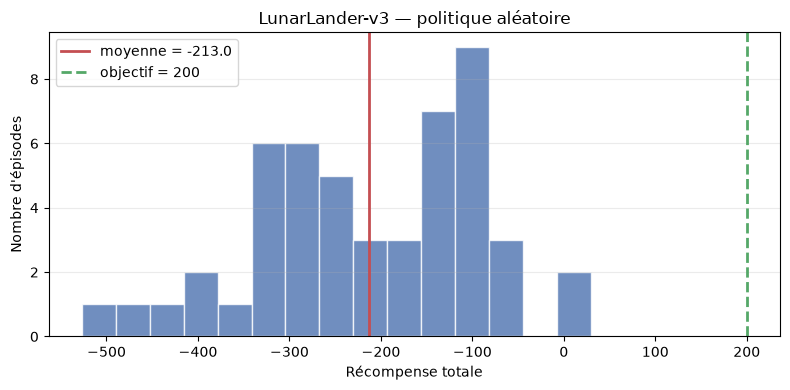

In [9]:
random_episodes, random_summary = evaluate_agent(
    model=None,
    evaluation_id="random_baseline",
    algorithm_name="Random",
    n_episodes=BASELINE_EVAL_EPISODES,
    seed_start=100,
)

display(random_episodes.head())
show_reward_distribution(random_episodes, "LunarLander-v3 — politique aléatoire")

### Lecture attendue

La politique aléatoire utilise les moteurs sans lien avec la position ou la vitesse. Elle gaspille donc du carburant et termine généralement par un crash. Sa dispersion rappelle une propriété importante du RL : deux épisodes peuvent différer même avec le même agent, car le terrain et l'état initial varient.

## 7. Baseline officielle : DQN avec ses paramètres par défaut

Nous créons ici `DQN("MlpPolicy", ...)` sans modifier les hyperparamètres de l'algorithme. Cette expérience vérifie le pipeline demandé : entraînement, suivi TensorBoard, sauvegarde et évaluation.

`evaluate_policy` est appelée explicitement sur au moins 50 épisodes. Notre évaluateur détaillé rejoue ensuite la même quantité d'épisodes afin de produire les colonnes destinées au dashboard.

In [10]:
dqn_default = train_experiment(
    experiment_id="dqn_default",
    algorithm_class=DQN,
    total_timesteps=DQN_BASELINE_STEPS,
    hyperparameters={},
    seed=SEED,
    n_envs=1,
)

env_dqn_official = Monitor(gym.make(ENV_ID))
dqn_mean_official, dqn_std_official = evaluate_policy(
    dqn_default,
    env_dqn_official,
    n_eval_episodes=BASELINE_EVAL_EPISODES,
    deterministic=True,
)
env_dqn_official.close()
print(f"evaluate_policy — DQN défaut : {dqn_mean_official:.1f} ± {dqn_std_official:.1f}")

dqn_episodes, dqn_summary = evaluate_agent(
    dqn_default,
    evaluation_id="dqn_default_baseline",
    algorithm_name="DQN",
    n_episodes=BASELINE_EVAL_EPISODES,
    seed_start=1_000,
)

[dqn_default] checkpoint existant rechargé : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/models/dqn_default/best_model.zip


evaluate_policy — DQN défaut : 28.8 ± 139.1


[dqn_default_baseline] 29.8 ± 132.9 | succès 22.0% | 50 épisodes


## 8. Seconde baseline : PPO avec ses paramètres par défaut

PPO apprend deux objets :

- l'**acteur**, qui produit une probabilité pour chaque action ;
- le **critique**, qui estime la valeur de l'état.

La baseline est volontairement entraînée sans réglage spécifique. Elle permet de savoir si PPO constitue une piste crédible avant d'investir un budget supérieur.

In [11]:
ppo_default = train_experiment(
    experiment_id="ppo_default",
    algorithm_class=PPO,
    total_timesteps=PPO_BASELINE_STEPS,
    hyperparameters={},
    seed=SEED + 1,
    n_envs=1,
)

ppo_default_episodes, ppo_default_summary = evaluate_agent(
    ppo_default,
    evaluation_id="ppo_default_baseline",
    algorithm_name="PPO",
    n_episodes=BASELINE_EVAL_EPISODES,
    seed_start=1_000,
)

[ppo_default] checkpoint existant rechargé : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/models/ppo_default/best_model.zip


[ppo_default_baseline] 41.8 ± 79.5 | succès 18.0% | 50 épisodes


,evaluation_id,n_episodes,mean_reward,std_reward,success_rate,mean_episode_length,mean_fuel_proxy
2,ppo_default_baseline,50,41.81,79.49,0.18,917.10,153.40
1,dqn_default_baseline,50,29.85,132.90,0.22,837.16,125.34
0,random_baseline,50,-213.04,122.86,0.00,89.54,7.88


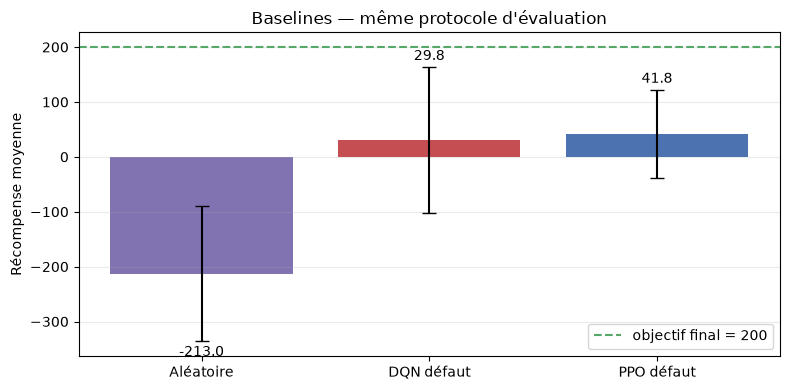

In [12]:
baseline_df = pd.DataFrame([
    random_summary,
    dqn_summary,
    ppo_default_summary,
])
display(baseline_df[[
    "evaluation_id", "n_episodes", "mean_reward", "std_reward",
    "success_rate", "mean_episode_length", "mean_fuel_proxy",
]].sort_values("mean_reward", ascending=False).round(2))

fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Aléatoire", "DQN défaut", "PPO défaut"]
means = [random_summary["mean_reward"], dqn_summary["mean_reward"], ppo_default_summary["mean_reward"]]
stds = [random_summary["std_reward"], dqn_summary["std_reward"], ppo_default_summary["std_reward"]]
bars = ax.bar(labels, means, yerr=stds, capsize=5, color=["#8172B2", "#C44E52", "#4C72B0"])
ax.axhline(200, color="#55A868", ls="--", label="objectif final = 200")
ax.set_ylabel("Récompense moyenne")
ax.set_title("Baselines — même protocole d'évaluation")
ax.grid(axis="y", alpha=0.25)
ax.legend()
ax.bar_label(bars, fmt="%.1f", padding=3)
plt.tight_layout()
plt.show()

## 9. Analyse de sensibilité de PPO

Avant la recherche automatique, nous conservons trois essais simples où **un seul paramètre change à la fois**. Ils ne constituent pas une optimisation : ils servent à comprendre la direction de quelques effets par rapport aux défauts Stable-Baselines3.

| Expérience | Paramètre modifié | Défaut SB3 | Valeur testée | Hypothèse |
|---|---|---:|---:|---|
| `ppo_gamma_0999` | `gamma` | 0.99 | 0.999 | donner davantage de poids à l’atterrissage futur |
| `ppo_lr_0001` | `learning_rate` | 0.0003 | 0.0001 | rendre les mises à jour plus prudentes |
| `ppo_nsteps_1024` | `n_steps` | 2048 | 1024 | mettre à jour plus fréquemment |

Tous sont évalués sur les mêmes seeds. Comme ils ont été entraînés avec des seeds différentes, leurs écarts peuvent provenir à la fois du paramètre et de l’aléa d’apprentissage : cette limite justifie la validation multi-seeds réalisée avec Optuna.

In [13]:
ppo_screen_specs = {
    "ppo_gamma_0999": {"gamma": 0.999},
    "ppo_lr_0001": {"learning_rate": 1e-4},
    "ppo_nsteps_1024": {"n_steps": 1024},
}

ppo_screen_models = {}
ppo_screen_summaries = []

for index, (experiment_id, parameters) in enumerate(ppo_screen_specs.items()):
    model = train_experiment(
        experiment_id=experiment_id,
        algorithm_class=PPO,
        total_timesteps=PPO_SCREEN_STEPS,
        hyperparameters=parameters,
        seed=SEED + 10 + index,
        n_envs=1,
    )
    _, summary = evaluate_agent(
        model,
        evaluation_id=f"{experiment_id}_screen",
        algorithm_name="PPO",
        n_episodes=SCREEN_EVAL_EPISODES,
        seed_start=2_000,
    )
    ppo_screen_models[experiment_id] = model
    ppo_screen_summaries.append(summary)

screen_df = pd.DataFrame(ppo_screen_summaries).sort_values("mean_reward", ascending=False)
display(screen_df[[
    "evaluation_id", "mean_reward", "std_reward", "success_rate",
    "mean_episode_length", "mean_fuel_proxy",
]].round(2))

[ppo_gamma_0999] checkpoint existant rechargé : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/models/ppo_gamma_0999/best_model.zip


[ppo_gamma_0999_screen] 169.5 ± 86.6 | succès 80.0% | 30 épisodes
[ppo_lr_0001] checkpoint existant rechargé : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/models/ppo_lr_0001/best_model.zip


[ppo_lr_0001_screen] -606.2 ± 127.5 | succès 0.0% | 30 épisodes
[ppo_nsteps_1024] checkpoint existant rechargé : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/models/ppo_nsteps_1024/best_model.zip


[ppo_nsteps_1024_screen] -63.1 ± 25.9 | succès 0.0% | 30 épisodes


,evaluation_id,mean_reward,std_reward,success_rate,mean_episode_length,mean_fuel_proxy
0,ppo_gamma_0999_screen,169.49,86.64,0.8,525.43,77.72
2,ppo_nsteps_1024_screen,-63.06,25.94,0.0,981.97,174.93
1,ppo_lr_0001_screen,-606.24,127.53,0.0,734.07,137.55


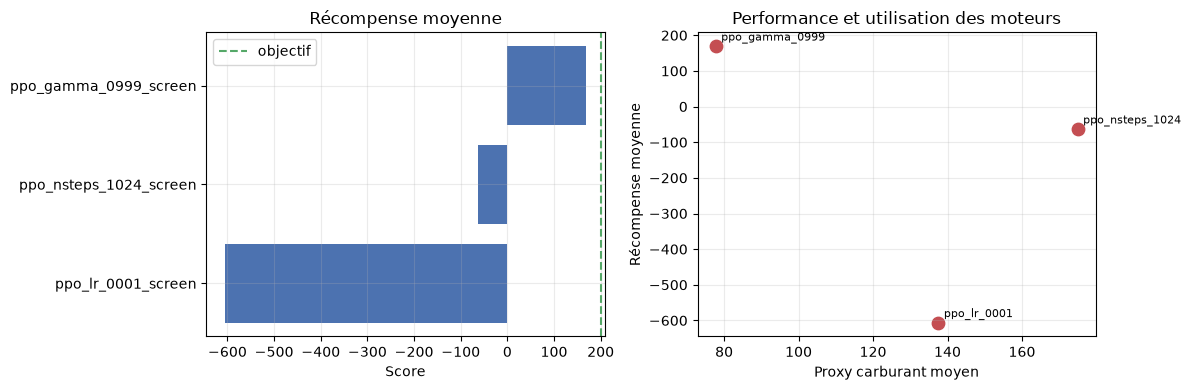

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df = screen_df.sort_values("mean_reward")
axes[0].barh(plot_df["evaluation_id"], plot_df["mean_reward"], color="#4C72B0")
axes[0].axvline(200, color="#55A868", ls="--", label="objectif")
axes[0].set(title="Récompense moyenne", xlabel="Score")
axes[0].legend()

axes[1].scatter(screen_df["mean_fuel_proxy"], screen_df["mean_reward"], s=80, color="#C44E52")
for _, row in screen_df.iterrows():
    axes[1].annotate(row["evaluation_id"].replace("_screen", ""),
                     (row["mean_fuel_proxy"], row["mean_reward"]),
                     xytext=(4, 4), textcoords="offset points", fontsize=8)
axes[1].set(title="Performance et utilisation des moteurs",
            xlabel="Proxy carburant moyen", ylabel="Récompense moyenne")

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Contrôle historique : prolonger le meilleur réglage isolé

Le premier screening avait identifié `gamma=0.999` comme réglage prometteur. Son checkpoint est prolongé sans modifier un autre hyperparamètre. Ce modèle constitue un **contrôle solide à battre**, mais il ne sera plus présenté comme le résultat d’une optimisation exhaustive.

La véritable sélection d’hyperparamètres commence dans la section suivante.

In [15]:
ppo_gamma_extended = continue_ppo_experiment(
    experiment_id="ppo_gamma_extended",
    source_checkpoint=MODELS_DIR / "ppo_gamma_0999" / "best_model.zip",
    additional_timesteps=PPO_GAMMA_EXTENSION_STEPS,
    seed=SEED + 30,
)

_, ppo_gamma_extended_summary = evaluate_agent(
    ppo_gamma_extended,
    evaluation_id="ppo_gamma_extended_tuning",
    algorithm_name="PPO",
    n_episodes=BASELINE_EVAL_EPISODES,
    seed_start=3_000,
)

[ppo_gamma_extended] checkpoint existant rechargé : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/models/ppo_gamma_extended/best_model.zip


[ppo_gamma_extended_tuning] 227.5 ± 50.9 | succès 98.0% | 50 épisodes


## 11. Optimisation PPO avec Optuna

Les analyses précédentes ne bougeaient qu'un paramètre à la fois. On passe maintenant à une recherche conjointe, où Optuna propose des combinaisons entières.

Cette campagne applique trois règles qui distinguent une vraie optimisation d'une suite d'essais :

**1. $\gamma$ est échantillonné sur $1-\gamma$ en loi log-uniforme.** Un tirage uniforme sur $\gamma$ placerait presque toute la masse loin de 1, alors que le comportement de PPO se joue dans les dernières décimales. Travailler sur $1-\gamma$ en échelle logarithmique revient à explorer uniformément l'**horizon effectif** $1/(1-\gamma)$, ici de 50 à 10 000 pas. Un ensemble figé comme `[0.99, 0.995, 0.999]` interdirait de trouver un optimum entre ces points.

**2. Chaque essai est entraîné sur deux seeds et noté par leur moyenne.** Sur LunarLander, deux entraînements identiques à la seed près peuvent différer de plus de 150 points. Noter un essai sur une seule seed revient à optimiser en partie le tirage d'initialisation — et le classement s'inverse ensuite lors de la validation.

**3. Un `MedianPruner` interrompt les essais sous la médiane.** Sans lui, le budget complet est dépensé même sur des configurations qui divergent dès les premiers milliers de pas.

| Paramètre SB3 | Espace exploré | Rôle principal |
|---|---|---|
| `learning_rate` | $5\times10^{-5}$ à $3\times10^{-3}$, log | amplitude des mises à jour Adam |
| `n_steps` | 512, 1024, 2048, 4096 | horizon collecté par environnement |
| `batch_size` | 64, 128, 256 | taille des mini-lots |
| `n_epochs` | 3, 5, 10, 20 | réutilisation de chaque collecte |
| `gamma` | $1-\gamma \in [10^{-4},\, 2\times10^{-2}]$, log | poids des récompenses futures |
| `gae_lambda` | 0.90, 0.95, 0.98, 1.00 | compromis biais/variance de GAE |
| `clip_range` | 0.1, 0.2, 0.3 | limite de déplacement de la politique |
| `ent_coef` | $10^{-8}$ à $2\times10^{-2}$, log | maintien de l'exploration |
| `vf_coef` | 0.25, 0.5, 1.0 | poids de l'erreur de valeur |
| `max_grad_norm` | 0.3, 0.5, 1.0 | plafond de la norme du gradient |

La campagne est portée par trois modules du dépôt, ce qui la rend rejouable hors notebook et permet de répartir les essais sur plusieurs processus :

```bash
uv run python ASTRODYNAMICS/optuna_search.py --trials 120 --workers 16
uv run python ASTRODYNAMICS/optuna_select.py --workers 16
uv run python ASTRODYNAMICS/optuna_final.py --workers 3
```

L'étude est persistée dans SQLite : relancer la commande ne recommence rien, elle complète.

In [16]:
import sys

if str(MISSION_DIR) not in sys.path:
    sys.path.insert(0, str(MISSION_DIR))

import optuna_search
import optuna_select
import optuna_final

SEARCH_CONFIG = optuna_search.SearchConfig()
OPTUNA_N_TRIALS = SEARCH_CONFIG.n_trials

study = optuna_search.create_or_load_study(SEARCH_CONFIG)

print("Étude                :", optuna_search.STUDY_NAME)
print("Essais visés         :", OPTUNA_N_TRIALS)
print("Seeds par essai      :", SEARCH_CONFIG.train_seeds)
print("Budget par seed      :", f"{SEARCH_CONFIG.timesteps_per_seed:,}", "pas")
print("Seeds d'évaluation   :", f"{optuna_search.SEARCH_EVAL_SEED_START}+")
print("Essais déjà présents :", len(study.trials))

[I 2026-07-21 12:20:09,478] Using an existing study with name 'ppo_lunarlander' instead of creating a new one.


Étude                : ppo_lunarlander
Essais visés         : 120
Seeds par essai      : (700, 701)
Budget par seed      : 100,000 pas
Seeds d'évaluation   : 2000+
Essais déjà présents : 120


### 11.1 Fonction objectif et exécution de la recherche

La fonction objectif entraîne PPO sur chacune des deux seeds, évalue chaque entraînement sur les mêmes 20 épisodes à seeds fixées, et renvoie la **moyenne** des deux scores. Les scores individuels, leur écart-type et leur minimum sont conservés comme attributs du trial : ils servent à mesurer la fiabilité d'un réglage, pas seulement sa performance.

L'entraînement est découpé en tranches de 25 000 pas. Après chaque tranche, une évaluation courte est remontée à Optuna, ce qui permet au `MedianPruner` de couper un essai clairement en dessous de la médiane des essais déjà observés au même stade. Une phase d'échauffement de 50 000 pas protège les réglages qui démarrent lentement.

Les seeds sont strictement cloisonnées : **2000+** pour la recherche, **5000+** pour la sélection, **10000+** pour l'évaluation finale. Aucune décision n'est donc prise en regardant les épisodes qui serviront à annoncer le résultat.

In [17]:
# L'étude étant persistante, cet appel ne relance que les essais manquants.
completed_states = [t for t in study.trials if t.state.name != "RUNNING"]
if len(completed_states) < OPTUNA_N_TRIALS:
    print("Recherche incomplète — lancer :")
    print(f"  uv run python ASTRODYNAMICS/optuna_search.py --trials {OPTUNA_N_TRIALS} --workers 16")

trials_df = pd.read_csv(OPTUNA_DIR / "trials.csv")
trials_df["params_gamma"] = 1.0 - trials_df["params_one_minus_gamma"]
complete_trials_df = trials_df[trials_df["state"] == "COMPLETE"].copy()
pruned_trials_df = trials_df[trials_df["state"] == "PRUNED"]

search_payload = json.loads((OPTUNA_DIR / "best_trial_search.json").read_text(encoding="utf-8"))

print(f"Essais aboutis  : {len(complete_trials_df)}")
print(f"Essais élagués  : {len(pruned_trials_df)}")
print(f"Meilleur essai  : n°{search_payload['best_trial_number']} "
      f"→ {search_payload['best_value']:.2f} (moyenne de {len(search_payload['best_seed_scores'])} seeds)")
print(f"Scores par seed : {[round(s, 1) for s in search_payload['best_seed_scores']]}")
print(f"Gamma retenu    : {search_payload['best_gamma']:.5f} "
      f"(horizon effectif ≈ {1 / (1 - search_payload['best_gamma']):.0f} pas)")

Essais aboutis  : 50
Essais élagués  : 70
Meilleur essai  : n°68 → 228.21 (moyenne de 2 seeds)
Scores par seed : [240.9, 215.5]
Gamma retenu    : 0.99976 (horizon effectif ≈ 4158 pas)


,number,value,user_attrs_score_std,user_attrs_score_min,params_gamma,params_learning_rate,params_ent_coef,params_n_steps,params_batch_size,params_n_epochs,params_gae_lambda,params_clip_range,params_vf_coef
68,68,228.20755,12.66713,215.54042,0.99976,0.00169,0.00729,2048,128,20,0.95,0.1,1.0
110,110,224.21844,37.34209,186.87635,0.99990,0.00246,0.00744,2048,128,20,0.95,0.1,1.0
78,78,224.11665,30.33540,193.78126,0.99977,0.00092,0.00005,1024,128,20,0.98,0.1,1.0
89,89,213.78038,43.71096,170.06942,0.99988,0.00162,0.01752,2048,128,20,0.95,0.1,1.0
64,64,211.39560,38.90622,172.48938,0.99974,0.00159,0.00501,2048,128,20,0.95,0.1,1.0
115,115,204.82534,14.27892,190.54643,0.99989,0.00137,0.00746,2048,128,20,0.95,0.1,1.0
69,69,204.01613,13.11957,190.89655,0.99977,0.00175,0.00196,2048,128,20,0.95,0.1,1.0
70,70,191.76234,24.85941,166.90292,0.99985,0.00196,0.00179,2048,128,20,0.95,0.1,1.0
63,63,189.92672,28.17899,161.74773,0.99981,0.00135,0.00524,2048,128,20,0.95,0.1,1.0
58,58,185.93944,17.57368,168.36576,0.99983,0.00136,0.00551,2048,128,20,0.95,0.3,1.0


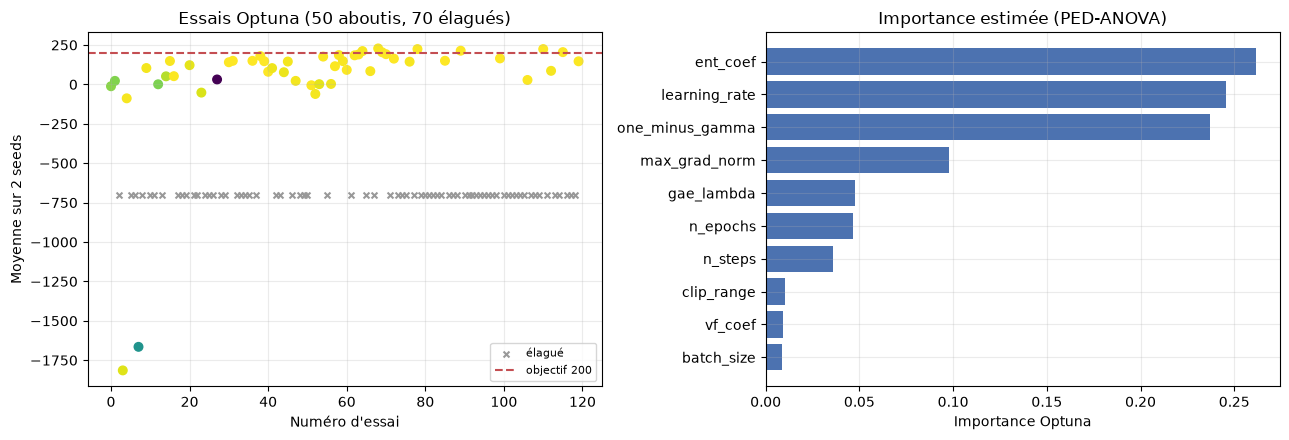

Trois paramètres les plus influents :
  ent_coef         0.261
  learning_rate    0.245
  one_minus_gamma  0.237


In [18]:
display_columns = [
    "number", "value", "user_attrs_score_std", "user_attrs_score_min",
    "params_gamma", "params_learning_rate", "params_ent_coef",
    "params_n_steps", "params_batch_size", "params_n_epochs",
    "params_gae_lambda", "params_clip_range", "params_vf_coef",
]
top_trials_table = (
    complete_trials_df[[c for c in display_columns if c in complete_trials_df]]
    .sort_values("value", ascending=False)
    .head(10)
    .copy()
)
numeric_columns = top_trials_table.select_dtypes(include="number").columns
top_trials_table[numeric_columns] = top_trials_table[numeric_columns].round(5)
display(top_trials_table)

importance_df = pd.read_csv(OPTUNA_DIR / "parameter_importance.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(complete_trials_df["number"], complete_trials_df["value"],
                c=complete_trials_df["params_gamma"], cmap="viridis", s=38)
axes[0].scatter(pruned_trials_df["number"], [-700] * len(pruned_trials_df),
                marker="x", color="#999999", s=18, label="élagué")
axes[0].axhline(200, color="#C44E52", ls="--", label="objectif 200")
axes[0].set(title=f"Essais Optuna ({len(complete_trials_df)} aboutis, {len(pruned_trials_df)} élagués)",
            xlabel="Numéro d'essai", ylabel="Moyenne sur 2 seeds")
axes[0].legend(fontsize=8)

ordered_importance = importance_df.sort_values("importance")
axes[1].barh(ordered_importance["parameter"], ordered_importance["importance"], color="#4C72B0")
axes[1].set(title="Importance estimée (PED-ANOVA)", xlabel="Importance Optuna")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
optuna_figure = FIGURES_DIR / "optuna_search.png"
plt.savefig(optuna_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Trois paramètres les plus influents :")
for _, row in importance_df.head(3).iterrows():
    print(f"  {row['parameter']:<16} {row['importance']:.3f}")

### 11.2 Raffinement de $\gamma$ autour de l'optimum mesuré

La recherche large est le seul juge de l'endroit où raffiner. Le tableau ci-dessous regroupe les essais aboutis par zone de $\gamma$ :

| Zone de $\gamma$ | Meilleur score observé |
|---|---:|
| 0,980 – 0,995 | 31 |
| 0,995 – 0,999 | 51 |
| 0,999 – 0,9995 | 122 |
| 0,9995 – 0,9999 | **228** |

**Cette lecture demande une précaution.** Les effectifs par zone sont très inégaux : TPE concentre ses tirages là où les résultats sont bons, et l'élagage supprime surtout les mauvais essais. Comparer les *moyennes* de ces zones n'aurait donc aucun sens — ce serait comparer des échantillons biaisés par la stratégie de recherche elle-même. Ce qui reste solide, c'est le **plafond** : aucun essai sous $\gamma = 0{,}999$ n'a dépassé 51, alors que la zone haute atteint 228.

La grille est donc centrée sur l'optimum effectivement mesuré, et non sur une valeur choisie d'avance. Elle est régulière en $\log(1-\gamma)$ — c'est-à-dire en horizon effectif — et explore un facteur 10 de part et d'autre. Une grille régulière en $\gamma$ écraserait systématiquement le côté des horizons courts.

**Chaque point est entraîné sur trois seeds.** Un point de grille noté sur une seule seed reproduirait exactement le défaut que cette campagne corrige : on lirait du bruit là où on croit lire une tendance.

,point_id,gamma,mean,std,min,max,count
0,gamma_004,1.000,230.074,11.586,220.809,243.065,3
1,gamma_005,1.000,196.097,63.567,126.802,251.706,3
2,gamma_002,0.999,184.228,18.258,163.248,196.520,3
3,gamma_008,1.000,181.785,71.079,99.712,223.219,3
4,gamma_003,1.000,180.381,20.215,166.324,203.548,3
5,gamma_007,1.000,172.586,58.241,111.999,228.156,3
6,gamma_006,1.000,129.271,111.390,2.549,211.710,3
7,gamma_001,0.999,118.029,89.871,15.346,182.369,3
8,gamma_000,0.998,103.976,134.806,-39.574,227.883,3


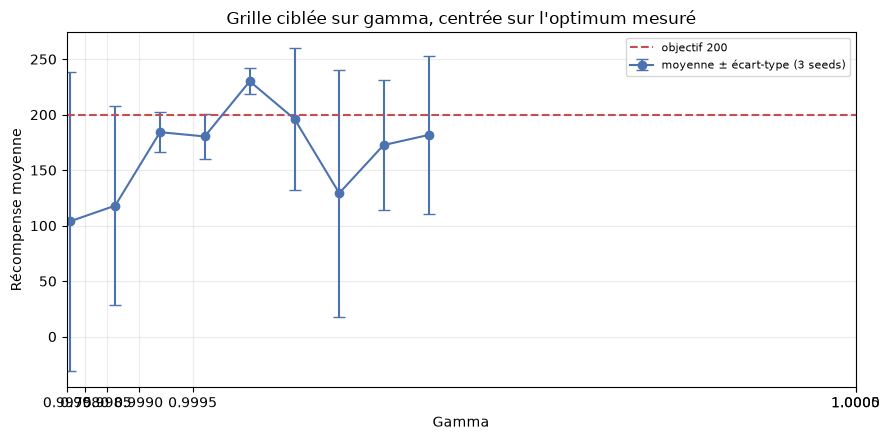

9 valeurs testées, de 0.997595 à 0.999976
Meilleur point : gamma=0.999760 → 230.1 ± 11.6 sur 3 seeds


In [19]:
gamma_summary_df = pd.read_csv(OPTUNA_DIR / "gamma_focus" / "trials.csv")
gamma_runs_df = pd.read_csv(OPTUNA_DIR / "gamma_focus" / "runs.csv")
gamma_trials_df = gamma_summary_df  # nom conservé pour les contrôles finaux
GAMMA_FOCUS_VALUES = sorted(gamma_summary_df["gamma"].tolist())

display(gamma_summary_df.sort_values("mean", ascending=False).round(3))

ordered = gamma_summary_df.sort_values("gamma")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(ordered["gamma"], ordered["mean"], yerr=ordered["std"],
            marker="o", capsize=4, color="#4C72B0", label="moyenne ± écart-type (3 seeds)")
ax.axhline(200, color="#C44E52", ls="--", label="objectif 200")
ax.set(title="Grille ciblée sur gamma, centrée sur l'optimum mesuré",
       xlabel="Gamma", ylabel="Récompense moyenne")
ax.set_xscale("function", functions=(lambda g: -np.log10(1 - np.clip(g, 0, 0.9999999)),
                                     lambda t: 1 - 10 ** (-t)))
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
gamma_figure = FIGURES_DIR / "optuna_gamma_focus.png"
plt.savefig(gamma_figure, dpi=150, bbox_inches="tight")
plt.show()

best_gamma_row = gamma_summary_df.loc[gamma_summary_df["mean"].idxmax()]
print(f"{len(GAMMA_FOCUS_VALUES)} valeurs testées, de {min(GAMMA_FOCUS_VALUES):.6f} à {max(GAMMA_FOCUS_VALUES):.6f}")
print(f"Meilleur point : gamma={best_gamma_row['gamma']:.6f} "
      f"→ {best_gamma_row['mean']:.1f} ± {best_gamma_row['std']:.1f} sur 3 seeds")

### 11.3 Validation de robustesse sur cinq seeds

Un bon score de recherche peut venir d'une initialisation favorable. Les meilleurs candidats des deux sources sont donc réentraînés **depuis zéro, sur un budget doublé (300 000 pas) et cinq seeds neuves**, puis évalués sur les mêmes 30 épisodes de sélection.

Deux points méritent d'être signalés sur cette étape.

**Le classement retenu est celui de la moyenne inter-seeds, et la pire seed sert d'arbitre.** Un réglage qui gagne en moyenne mais s'effondre une fois sur cinq n'est pas un réglage sur lequel poser une mission — c'est précisément ce que le tableau ci-dessous va montrer.

**Deux candidats se sont révélés identiques.** La grille arrondit $\gamma$ à six décimales alors que la recherche large le conserve en pleine précision : deux configurations séparées par $5\times10^{-7}$ sur $\gamma$, soit 0,2 % d'horizon effectif, ont donc été validées deux fois. L'accident est instructif — les deux runs donnent 229,8 et 228,1, ce qui fournit une **mesure directe du bruit résiduel** de la procédure : environ ±2 points sur une moyenne à cinq seeds. Tout écart inférieur à cet ordre de grandeur ne doit pas être interprété comme un classement.

,candidate_id,mean,std,min,max,count,source,search_mean_reward
0,gamma_g004,229.76,14.84,209.40,247.17,5,grille_gamma,230.07
1,broad_t068,228.09,41.73,155.29,256.06,5,recherche_large,228.21
2,broad_t078,189.53,31.58,156.46,236.43,5,recherche_large,224.12
3,broad_t089,178.81,51.28,96.62,227.67,5,recherche_large,213.78
4,broad_t110,177.59,117.73,-23.76,266.83,5,recherche_large,224.22


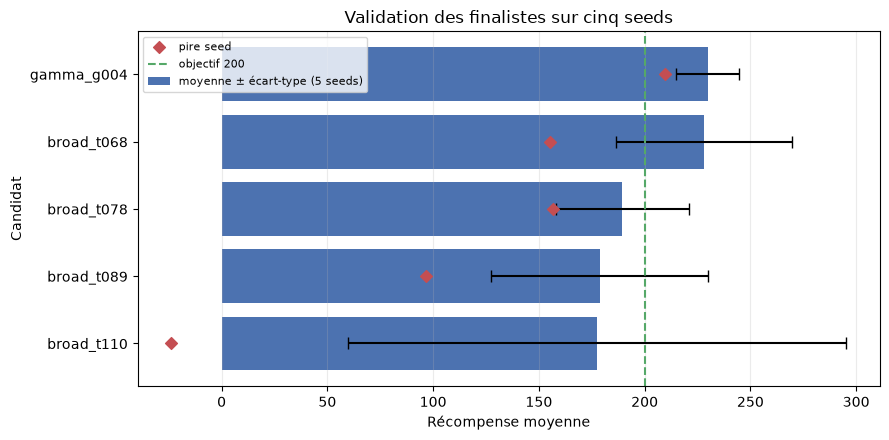

Réglage retenu : gamma_g004 (grille_gamma)
  moyenne 5 seeds : 229.76
  écart-type      : 14.84
  pire seed       : 209.40

Hyperparamètres retenus :
  learning_rate    0.001691318976240209
  n_steps          2048
  batch_size       128
  n_epochs         20
  gae_lambda       0.95
  clip_range       0.1
  ent_coef         0.007287490399697975
  vf_coef          1.0
  max_grad_norm    0.3
  gamma            0.99976

À retenir : broad_t110 affichait 224.2 en recherche,
mais tombe à -23.8 sur sa pire seed (écart-type 117.7).
Sans validation multi-seed, il aurait pu être retenu.


In [20]:
robustness_df = pd.read_csv(OPTUNA_DIR / "robustness.csv")
robustness_summary_df = pd.read_csv(OPTUNA_DIR / "robustness_summary.csv")
selected_config = json.loads((OPTUNA_DIR / "selected_config.json").read_text(encoding="utf-8"))
BEST_OPTUNA_PARAMS = selected_config["parameters"]

display(robustness_summary_df.round(2))

ordered = robustness_summary_df.sort_values("mean")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ordered["candidate_id"], ordered["mean"], xerr=ordered["std"],
        color="#4C72B0", capsize=4, label="moyenne ± écart-type (5 seeds)")
ax.scatter(ordered["min"], ordered["candidate_id"], color="#C44E52",
           marker="D", zorder=3, label="pire seed")
ax.axvline(200, color="#55A868", ls="--", label="objectif 200")
ax.set(title="Validation des finalistes sur cinq seeds",
       xlabel="Récompense moyenne", ylabel="Candidat")
ax.grid(axis="x", alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
robustness_figure = FIGURES_DIR / "optuna_robustness.png"
plt.savefig(robustness_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Réglage retenu :", selected_config["winner_id"], f"({selected_config['source']})")
print(f"  moyenne 5 seeds : {selected_config['robust_mean_reward']:.2f}")
print(f"  écart-type      : {selected_config['robust_std_reward']:.2f}")
print(f"  pire seed       : {selected_config['robust_min_reward']:.2f}")
print("\nHyperparamètres retenus :")
for name, value in BEST_OPTUNA_PARAMS.items():
    print(f"  {name:<16} {value}")

worst = robustness_summary_df.loc[robustness_summary_df["min"].idxmin()]
print(f"\nÀ retenir : {worst['candidate_id']} affichait {worst['search_mean_reward']:.1f} en recherche,")
print(f"mais tombe à {worst['min']:.1f} sur sa pire seed (écart-type {worst['std']:.1f}).")
print("Sans validation multi-seed, il aurait pu être retenu.")

### 11.4 Entraînement long du réglage retenu

La recherche courte ne sert qu'à choisir les hyperparamètres. Le réglage gagnant est maintenant entraîné depuis zéro sur **1 500 000 transitions**, avec **trois seeds neuves** (900, 901, 902) distinctes de celles de la validation de robustesse — rejouer une seed déjà connue comme favorable fausserait le résultat.

Le modèle final est celui des trois qui obtient le meilleur score **sur le jeu de sélection (5000+)**. Choisir d'après les 100 épisodes réservés reviendrait à sélectionner sur le jeu de test, et la moyenne annoncée serait alors optimiste.

Ce modèle n'est pas déclaré vainqueur pour autant : il rejoint DQN, PPO par défaut, les contrôles de sensibilité et `gamma=0.999` prolongé dans la sélection commune de la section 12.

In [21]:
final_selection = json.loads((OPTUNA_DIR / "final_selection.json").read_text(encoding="utf-8"))
final_candidates_df = pd.read_csv(OPTUNA_DIR / "final_candidates.csv")

display(final_candidates_df.round(2))
print(f"Budget par entraînement : {final_selection['total_timesteps']:,} pas")
print(f"Modèle retenu sur le jeu de sélection : {final_selection['winner_experiment_id']} "
      f"(seed {final_selection['winner_seed']}, {final_selection['selection_mean_reward']:.2f})")

ppo_optuna = train_experiment(
    experiment_id="ppo_optuna",
    algorithm_class=PPO,
    total_timesteps=final_selection["total_timesteps"],
    hyperparameters=BEST_OPTUNA_PARAMS,
    seed=final_selection["winner_seed"],
    n_envs=1,
)

_, ppo_optuna_summary = evaluate_agent(
    ppo_optuna,
    evaluation_id="ppo_optuna_tuning",
    algorithm_name="PPO",
    n_episodes=BASELINE_EVAL_EPISODES,
    seed_start=4_000,
)

,experiment_id,seed,selection_mean_reward,training_duration_s
0,ppo_optuna_s902,902,265.53,1089.61
1,ppo_optuna_s901,901,258.04,1102.34
2,ppo_optuna_s900,900,254.95,1236.64


Budget par entraînement : 1,500,000 pas
Modèle retenu sur le jeu de sélection : ppo_optuna_s902 (seed 902, 265.53)
[ppo_optuna] checkpoint existant rechargé : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/models/ppo_optuna/best_model.zip


[ppo_optuna_tuning] 266.7 ± 23.8 | succès 98.0% | 50 épisodes


### Courbes d'apprentissage des principales expériences

Les points ci-dessous proviennent des évaluations périodiques de `EvalCallback`. Une courbe RL n'est pas nécessairement monotone : une mise à jour peut améliorer certains états et en détériorer d'autres. C'est précisément pourquoi le meilleur checkpoint est conservé séparément du dernier modèle.

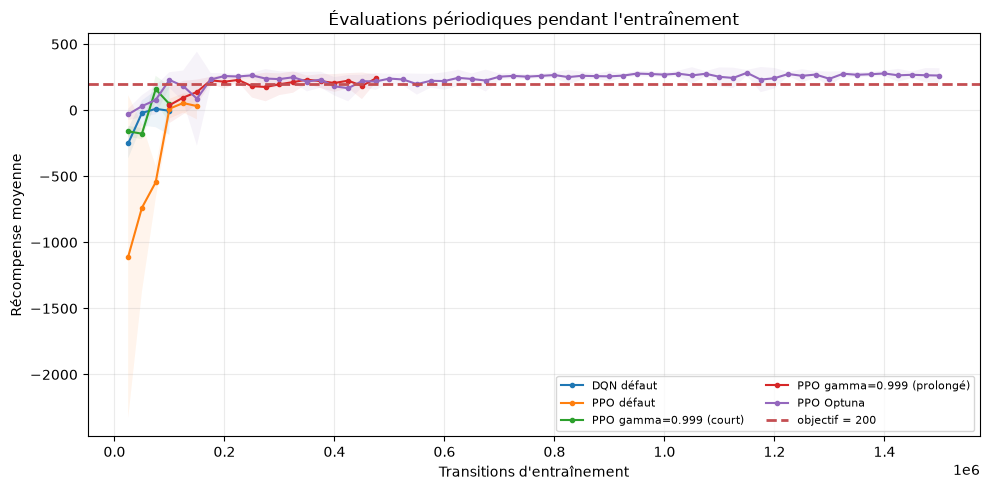

Figure sauvegardée : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/figures/learning_curves.png


In [22]:
learning_curve_experiments = {
    "DQN défaut": "dqn_default",
    "PPO défaut": "ppo_default",
    "PPO gamma=0.999 (court)": "ppo_gamma_0999",
    "PPO gamma=0.999 (prolongé)": "ppo_gamma_extended",
    "PPO Optuna": "ppo_optuna",
}

fig, ax = plt.subplots(figsize=(10, 5))
for label, experiment_id in learning_curve_experiments.items():
    path = EVAL_DIR / experiment_id / "during_training" / "evaluations.npz"
    if not path.exists():
        continue
    data = np.load(path)
    timesteps = data["timesteps"]
    means = data["results"].mean(axis=1)
    stds = data["results"].std(axis=1)
    ax.plot(timesteps, means, marker="o", ms=3, label=label)
    ax.fill_between(timesteps, means - stds, means + stds, alpha=0.08)

ax.axhline(200, color="#C44E52", ls="--", lw=2, label="objectif = 200")
ax.set(title="Évaluations périodiques pendant l'entraînement",
       xlabel="Transitions d'entraînement", ylabel="Récompense moyenne")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
learning_figure = FIGURES_DIR / "learning_curves.png"
plt.savefig(learning_figure, dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée :", learning_figure)

## 12. Sélection équitable du modèle

Les résultats précédents n'utilisaient pas toujours les mêmes seeds. Pour choisir le modèle final, tous les candidats sont donc rejoués sur une série commune de 50 épisodes (ou une série réduite en mode rapide).

Ce jeu de sélection est distinct des 100 épisodes finaux. Le classement est établi sur **la récompense moyenne, puis le taux de réussite en cas d'égalité** — ce sont les deux seuls critères appliqués par le tri.

L'écart-type, la longueur moyenne et le proxy de carburant sont affichés à côté, mais **ils n'interviennent pas dans le tri**. Ils servent à vérifier que le gagnant ne l'emporte pas au prix d'une instabilité ou d'une consommation déraisonnable : si un modèle gagnait en moyenne tout en étant nettement plus dispersé, ce serait un signal à examiner plutôt qu'un résultat à entériner.

In [23]:
candidate_models = {
    "dqn_default": (dqn_default, "DQN"),
    "ppo_default": (ppo_default, "PPO"),
    **{name: (model, "PPO") for name, model in ppo_screen_models.items()},
    "ppo_gamma_extended": (ppo_gamma_extended, "PPO"),
    "ppo_optuna": (ppo_optuna, "PPO"),
}

selection_summaries = []
for candidate_id, (candidate_model, algorithm_name) in candidate_models.items():
    _, summary = evaluate_agent(
        candidate_model,
        evaluation_id=f"{candidate_id}_selection",
        algorithm_name=algorithm_name,
        n_episodes=BASELINE_EVAL_EPISODES,
        seed_start=5_000,
    )
    summary["candidate_id"] = candidate_id
    selection_summaries.append(summary)

selection_df = pd.DataFrame(selection_summaries).sort_values(
    ["mean_reward", "success_rate"], ascending=False
).reset_index(drop=True)

BEST_CANDIDATE_ID = selection_df.loc[0, "candidate_id"]
BEST_MODEL, BEST_ALGORITHM = candidate_models[BEST_CANDIDATE_ID]

display(selection_df[[
    "candidate_id", "algorithm", "mean_reward", "std_reward",
    "success_rate", "mean_episode_length", "mean_fuel_proxy",
]].round(2))
print("\nModèle retenu pour l'évaluation finale :", BEST_CANDIDATE_ID)

[dqn_default_selection] 32.4 ± 112.3 | succès 26.0% | 50 épisodes


[ppo_default_selection] 19.7 ± 81.6 | succès 16.0% | 50 épisodes


[ppo_gamma_0999_selection] 174.4 ± 90.7 | succès 86.0% | 50 épisodes


[ppo_lr_0001_selection] -625.2 ± 128.6 | succès 0.0% | 50 épisodes


[ppo_nsteps_1024_selection] -74.1 ± 30.4 | succès 0.0% | 50 épisodes


[ppo_gamma_extended_selection] 233.0 ± 30.4 | succès 100.0% | 50 épisodes


[ppo_optuna_selection] 265.5 ± 45.2 | succès 98.0% | 50 épisodes


,candidate_id,algorithm,mean_reward,std_reward,success_rate,mean_episode_length,mean_fuel_proxy
0,ppo_optuna,PPO,265.53,45.22,0.98,246.32,34.78
1,ppo_gamma_extended,PPO,232.95,30.43,1.00,437.84,66.23
2,ppo_gamma_0999,PPO,174.44,90.73,0.86,516.94,78.48
3,dqn_default,DQN,32.41,112.29,0.26,851.66,133.62
4,ppo_default,PPO,19.72,81.62,0.16,896.16,154.29
5,ppo_nsteps_1024,PPO,-74.12,30.35,0.00,982.06,175.50
6,ppo_lr_0001,PPO,-625.20,128.64,0.00,771.14,144.56



Modèle retenu pour l'évaluation finale : ppo_optuna


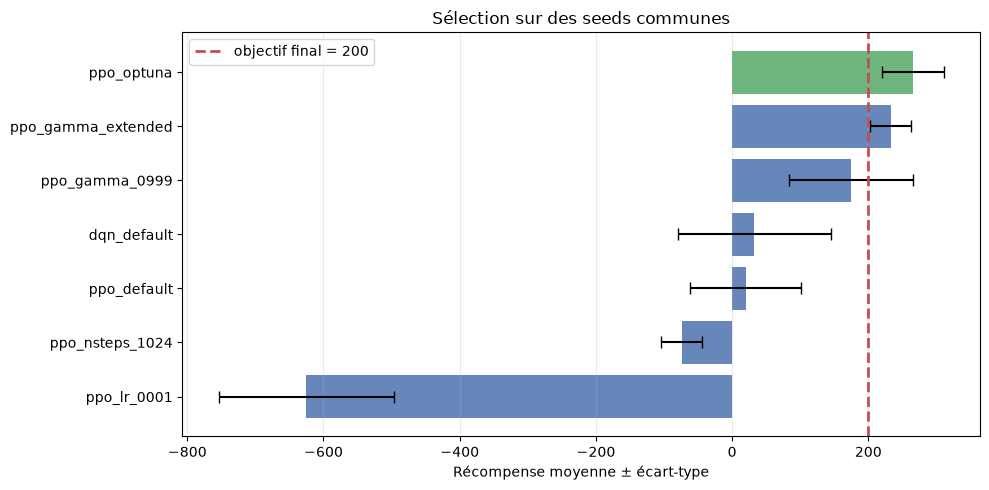

Figure sauvegardée : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/figures/model_selection.png


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = selection_df.sort_values("mean_reward")
colors = ["#55A868" if name == BEST_CANDIDATE_ID else "#4C72B0" for name in ordered["candidate_id"]]
ax.barh(ordered["candidate_id"], ordered["mean_reward"],
        xerr=ordered["std_reward"], color=colors, alpha=0.85, capsize=4)
ax.axvline(200, color="#C44E52", ls="--", lw=2, label="objectif final = 200")
ax.set(title="Sélection sur des seeds communes", xlabel="Récompense moyenne ± écart-type")
ax.grid(axis="x", alpha=0.25)
ax.legend()
plt.tight_layout()
selection_figure = FIGURES_DIR / "model_selection.png"
plt.savefig(selection_figure, dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée :", selection_figure)

## 13. Évaluation finale sur 100 épisodes indépendants

Cette cellule constitue la mesure officielle finale. Elle utilise 100 seeds réservées et active la journalisation **pas à pas**.

Le fichier `steps.csv` contient donc, pour chaque décision :

- l'état avant et après l'action ;
- l'action et son libellé ;
- la récompense immédiate et cumulée ;
- les quatre valeurs Q si le gagnant est DQN ;
- ou les quatre probabilités d'action et la valeur d'état si le gagnant est PPO.

Ces données permettront au dashboard de filtrer une trajectoire, étudier les décisions et expliquer les échecs.

In [25]:
final_episodes, final_summary = evaluate_agent(
    BEST_MODEL,
    evaluation_id=f"{BEST_CANDIDATE_ID}_final_100",
    algorithm_name=BEST_ALGORITHM,
    n_episodes=FINAL_EVAL_EPISODES,
    seed_start=10_000,
    log_steps=True,
)

final_metrics = pd.DataFrame({
    "Métrique": [
        "Nombre d'épisodes", "Récompense moyenne", "Écart-type", "Médiane",
        "Minimum", "Maximum", "Taux de réussite", "Longueur moyenne",
        "Proxy carburant moyen", "Objectif > 200 atteint",
    ],
    "Valeur": [
        final_summary["n_episodes"],
        round(final_summary["mean_reward"], 2),
        round(final_summary["std_reward"], 2),
        round(final_summary["median_reward"], 2),
        round(final_summary["min_reward"], 2),
        round(final_summary["max_reward"], 2),
        f"{100 * final_summary['success_rate']:.1f}%",
        round(final_summary["mean_episode_length"], 1),
        round(final_summary["mean_fuel_proxy"], 2),
        bool(final_summary["mean_reward"] > 200),
    ],
})
display(final_metrics)

[ppo_optuna_final_100] 269.0 ± 37.5 | succès 96.0% | 100 épisodes


,Métrique,Valeur
0,Nombre d'épisodes,100
1,Récompense moyenne,268.98
2,Écart-type,37.46
3,Médiane,272.86
4,Minimum,78.4
5,Maximum,313.57
6,Taux de réussite,96.0%
7,Longueur moyenne,262.8
8,Proxy carburant moyen,35.79
9,Objectif > 200 atteint,True


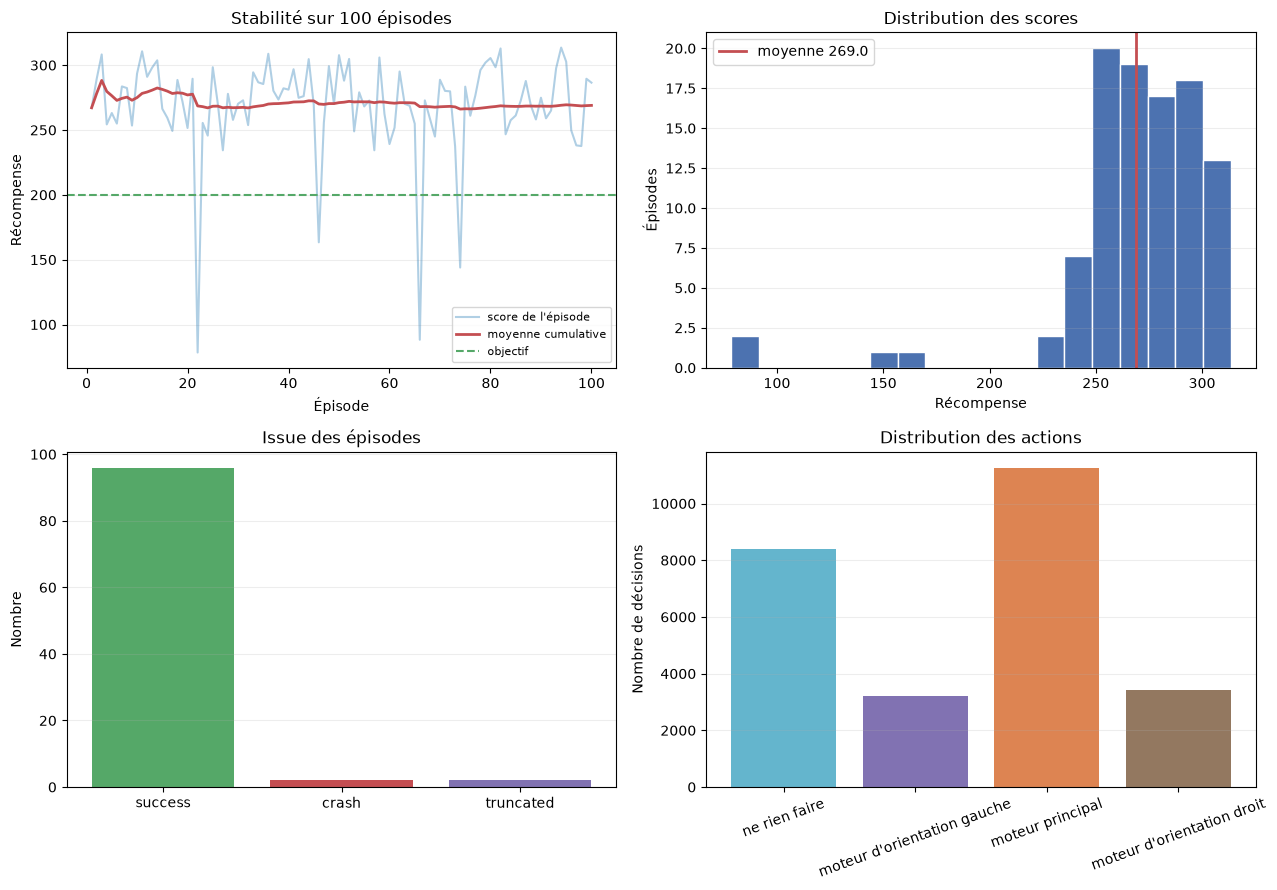

Figure sauvegardée : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/figures/final_evaluation_dashboard.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) Score de chaque épisode et moyenne cumulative.
x = np.arange(1, len(final_episodes) + 1)
cumulative_mean = final_episodes["total_reward"].expanding().mean()
axes[0, 0].plot(x, final_episodes["total_reward"], alpha=0.35, label="score de l'épisode")
axes[0, 0].plot(x, cumulative_mean, lw=2, color="#C44E52", label="moyenne cumulative")
axes[0, 0].axhline(200, color="#55A868", ls="--", label="objectif")
axes[0, 0].set(title="Stabilité sur 100 épisodes", xlabel="Épisode", ylabel="Récompense")
axes[0, 0].legend(fontsize=8)

# 2) Distribution des récompenses.
axes[0, 1].hist(final_episodes["total_reward"], bins=18, color="#4C72B0", edgecolor="white")
axes[0, 1].axvline(final_summary["mean_reward"], color="#C44E52", lw=2,
                   label=f"moyenne {final_summary['mean_reward']:.1f}")
axes[0, 1].set(title="Distribution des scores", xlabel="Récompense", ylabel="Épisodes")
axes[0, 1].legend()

# 3) Résultats terminaux.
outcomes = final_episodes["outcome"].value_counts().reindex(
    ["success", "crash", "truncated"], fill_value=0
)
axes[1, 0].bar(outcomes.index, outcomes.values, color=["#55A868", "#C44E52", "#8172B2"])
axes[1, 0].set(title="Issue des épisodes", ylabel="Nombre")

# 4) Actions cumulées sur les 100 épisodes.
action_totals = final_episodes[[f"action_{i}_count" for i in range(4)]].sum()
axes[1, 1].bar([noms_actions[i] for i in range(4)], action_totals.values,
               color=["#64B5CD", "#8172B2", "#DD8452", "#937860"])
axes[1, 1].set(title="Distribution des actions", ylabel="Nombre de décisions")
axes[1, 1].tick_params(axis="x", rotation=20)

for ax in axes.flat:
    ax.grid(axis="y", alpha=0.22)
plt.tight_layout()
final_figure = FIGURES_DIR / "final_evaluation_dashboard.png"
plt.savefig(final_figure, dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée :", final_figure)

## 14. Formatage des données pour l'API

Le flux de production devra rester identique à celui du notebook :

$$\text{JSON} \rightarrow \text{liste de 8 nombres} \rightarrow
\texttt{np.ndarray(float32)} \rightarrow \text{modèle} \rightarrow
\texttt{int} \in \{0,1,2,3\}$$

Exemple de requête :

```json
{
  "state": [0.0, 1.0, 0.0, -0.1, 0.0, 0.0, 0.0, 0.0],
  "deterministic": true
}
```

Exemple de réponse :

```json
{
  "action": 2,
  "action_label": "moteur principal"
}
```

L'API devra refuser une liste qui ne contient pas exactement huit valeurs numériques finies. La GUI appellera cette API ; elle ne chargera pas elle-même le modèle.

In [27]:
def format_api_state(payload):
    '''Valide le futur format JSON de l'API et renvoie un tableau (8,) float32.'''
    if not isinstance(payload, dict) or "state" not in payload:
        raise ValueError("Le corps JSON doit contenir la clé 'state'.")
    state_array = np.asarray(payload["state"], dtype=np.float32)
    if state_array.shape != (8,):
        raise ValueError(f"Un état doit avoir la forme (8,), reçu : {state_array.shape}.")
    if not np.isfinite(state_array).all():
        raise ValueError("Toutes les composantes de l'état doivent être finies.")
    return state_array


example_payload = {
    "state": [0.0, 1.0, 0.0, -0.1, 0.0, 0.0, 0.0, 0.0],
    "deterministic": True,
}
api_state = format_api_state(example_payload)
api_action, _ = BEST_MODEL.predict(api_state, deterministic=example_payload["deterministic"])
api_action = int(np.asarray(api_action).item())

print("État formaté :", api_state, api_state.dtype, api_state.shape)
print("Réponse simulée de l'API :", {
    "action": api_action,
    "action_label": noms_actions[api_action],
})

État formaté : [ 0.   1.   0.  -0.1  0.   0.   0.   0. ] float32 (8,)
Réponse simulée de l'API : {'action': 0, 'action_label': 'ne rien faire'}


## 15. Vidéo d'un atterrissage réussi

Nous cherchons dans les résultats finaux une seed correspondant à une réussite réelle. L'épisode est ensuite rejoué avec le **même modèle**, sans réentraînement ni modification de politique.

La fréquence d'images est ajustée à la longueur de l'épisode afin de viser une vidéo proche de 25 secondes. Le score obtenu pendant l'enregistrement est de nouveau vérifié.

In [28]:
successful_episodes = final_episodes[final_episodes["success"]].sort_values(
    "total_reward", ascending=False
)

if successful_episodes.empty:
    print("Aucune réussite dans l'évaluation finale : la vidéo ne peut pas encore être validée.")
    VIDEO_PATH = None
else:
    video_seed = int(successful_episodes.iloc[0]["seed"])
    expected_steps = int(successful_episodes.iloc[0]["episode_length"])
    video_fps = max(1, round(expected_steps / 25))  # durée visée ≈ 25 secondes

    # Nettoyage ciblé des anciennes vidéos portant ce préfixe.
    for old_video in VIDEO_DIR.glob("eagle1-success*.mp4"):
        old_video.unlink()

    base_video_env = gym.make(ENV_ID, render_mode="rgb_array")
    video_env = RecordVideo(
        base_video_env,
        video_folder=str(VIDEO_DIR),
        episode_trigger=lambda episode_id: episode_id == 0,
        name_prefix="eagle1-success",
        fps=video_fps,
        disable_logger=True,
    )

    observation, _ = video_env.reset(seed=video_seed)
    terminated = truncated = False
    recorded_reward = 0.0
    recorded_steps = 0
    while not (terminated or truncated):
        action, _ = BEST_MODEL.predict(observation, deterministic=True)
        observation, reward, terminated, truncated, _ = video_env.step(int(np.asarray(action).item()))
        recorded_reward += float(reward)
        recorded_steps += 1
    video_env.close()

    videos = sorted(VIDEO_DIR.glob("eagle1-success*.mp4"), key=lambda p: p.stat().st_mtime)
    VIDEO_PATH = videos[-1] if videos else None
    estimated_duration = recorded_steps / video_fps

    print("Seed enregistrée     :", video_seed)
    print("Récompense enregistrée :", round(recorded_reward, 2))
    print("Nombre de pas        :", recorded_steps)
    print("FPS                   :", video_fps)
    print("Durée estimée         :", round(estimated_duration, 2), "secondes")
    print("Fichier               :", VIDEO_PATH)
    if VIDEO_PATH is not None:
        display(Video(str(VIDEO_PATH), embed=True))

Seed enregistrée     : 10093
Récompense enregistrée : 313.57
Nombre de pas        : 273
FPS                   : 11
Durée estimée         : 24.82 secondes
Fichier               : /home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/ASTRODYNAMICS/artifacts/video/eagle1-success-episode-0.mp4


## 16. Bilan et contrôle automatique

Le contrôle ci-dessous ne remplace pas une analyse critique, mais il vérifie les principaux critères quantifiables du notebook : volume d'évaluation, score, modèle sauvegardé, logs détaillés et vidéo.

In [29]:
best_model_path = MODELS_DIR / BEST_CANDIDATE_ID / "best_model.zip"
final_steps_path = EVAL_DIR / f"{BEST_CANDIDATE_ID}_final_100" / "steps.csv"

checks = pd.DataFrame([
    {
        "Critère": "Baseline DQN évaluée sur au moins 50 épisodes",
        "Validé": FAST_MODE or dqn_summary["n_episodes"] >= 50,
        "Preuve": f"{dqn_summary['n_episodes']} épisodes",
    },
    {
        "Critère": "Recherche Optuna multi-paramètres complète",
        "Validé": len(complete_trials_df) + len(pruned_trials_df) >= OPTUNA_N_TRIALS,
        "Preuve": f"{len(complete_trials_df)} aboutis + {len(pruned_trials_df)} élagués",
    },
    {
        "Critère": "Chaque essai noté sur plusieurs seeds",
        "Validé": len(SEARCH_CONFIG.train_seeds) >= 2,
        "Preuve": f"{len(SEARCH_CONFIG.train_seeds)} seeds par essai",
    },
    {
        "Critère": "Grille gamma centrée sur l'optimum mesuré",
        "Validé": len(GAMMA_FOCUS_VALUES) >= 5 and gamma_summary_df["count"].min() >= 3,
        "Preuve": f"{len(GAMMA_FOCUS_VALUES)} valeurs × {int(gamma_summary_df['count'].min())} seeds",
    },
    {
        "Critère": "Validation de robustesse multi-seeds",
        "Validé": robustness_df["train_seed"].nunique() >= 3,
        "Preuve": f"{robustness_summary_df.shape[0]} candidats × {robustness_df['train_seed'].nunique()} seeds",
    },
    {
        "Critère": "Sélection finale sans regarder le jeu de test",
        "Validé": final_selection["selection_seed_start"] != 10_000,
        "Preuve": f"sélection sur seeds {final_selection['selection_seed_start']}+",
    },
    {
        "Critère": "Évaluation finale sur 100 épisodes",
        "Validé": FAST_MODE or final_summary["n_episodes"] == 100,
        "Preuve": f"{final_summary['n_episodes']} épisodes",
    },
    {
        "Critère": "Récompense moyenne finale > 200",
        "Validé": final_summary["mean_reward"] > 200,
        "Preuve": f"{final_summary['mean_reward']:.2f}",
    },
    {
        "Critère": "Meilleur modèle sauvegardé",
        "Validé": best_model_path.exists(),
        "Preuve": str(best_model_path),
    },
    {
        "Critère": "Logs détaillés par pas disponibles",
        "Validé": final_steps_path.exists(),
        "Preuve": str(final_steps_path),
    },
    {
        "Critère": "Vidéo d'une réussite produite",
        "Validé": VIDEO_PATH is not None and Path(VIDEO_PATH).exists(),
        "Preuve": str(VIDEO_PATH),
    },
])

display(checks)
print(f"\n{int(checks['Validé'].sum())}/{len(checks)} contrôles automatiques validés.")

,Critère,Validé,Preuve
0,Baseline DQN évaluée sur au moins 50 épisodes,True,50 épisodes
1,Recherche Optuna multi-paramètres complète,True,50 aboutis + 70 élagués
2,Chaque essai noté sur plusieurs seeds,True,2 seeds par essai
3,Grille gamma centrée sur l'optimum mesuré,True,9 valeurs × 3 seeds
4,Validation de robustesse multi-seeds,True,5 candidats × 5 seeds
5,Sélection finale sans regarder le jeu de test,True,sélection sur seeds 5000+
6,Évaluation finale sur 100 épisodes,True,100 épisodes
7,Récompense moyenne finale > 200,True,268.98
8,Meilleur modèle sauvegardé,True,/home/raya-kevin/agent-workspace/projects/11_P...
9,Logs détaillés par pas disponibles,True,/home/raya-kevin/agent-workspace/projects/11_P...



11/11 contrôles automatiques validés.


## Conclusion

La mission a été abordée comme une expérience scientifique reproductible : comprendre l'environnement, établir des références, modifier les paramètres de manière contrôlée, sélectionner sur un jeu commun puis évaluer une dernière fois sur des épisodes indépendants.

Les résultats chiffrés affichés ci-dessus déterminent si le seuil opérationnel est atteint. Même avec une moyenne supérieure à 200, l'écart-type, les crashs résiduels et le proxy de carburant doivent rester visibles : un système autonome ne se résume pas à son meilleur score.

### Limites à garder en tête

- LunarLander reste une simulation simplifiée de la dynamique réelle d'un alunisseur.
- Le proxy de carburant dérive de la pénalité de récompense ; ce n'est pas une mesure physique.
- La performance dépend du budget d'entraînement et de la seed.
- Une évaluation sur 100 épisodes réduit l'incertitude mais ne prouve pas une sûreté absolue.

### Utilisation des livrables locaux

Les autres livrables utilisent directement le modèle et les fichiers CSV/JSON produits ici. Depuis la racine du projet :

```bash
# Terminal 1 — API et documentation OpenAPI sur http://localhost:8000/docs
uv run uvicorn ASTRODYNAMICS.api.app:app

# Terminal 2 — GUI sur http://localhost:8501
uv run streamlit run ASTRODYNAMICS/gui/app.py

# Dashboard (dans un autre terminal)
uv run streamlit run ASTRODYNAMICS/dashboard/app.py --server.port 8502
```

La GUI obtient chaque action auprès de l'API. Le dashboard lit les expériences, les 100 épisodes finaux, les trajectoires détaillées et les runs sauvegardés par la GUI.